Zadaniem klasyfikacyjnym dla modeli było ustalenie liczby "1" nad przekątną w postaci Jordana.

Macierze losowe są generowane w następujący sposób:
* stwórz macierz $J$ z odpowiednią liczbą $1$ nad przekątną oraz z wartościami własnymi $\lambda = 1$ na przekątnej
* wylosuj macierz $S$, taką że $\kappa(S) < 10^5$
* $ X = S^{-1} J S$
* macierz jest normalizowana (względem normy Frobeniusa): $ X = 1/\|X\|_F X$

Losowanie macierzy $S$ odbywa się wg różnych metod:
* `random`: $S$ generowana przez `np.random.rand(d, d)`
* `upper`: $S$ jest górnotrójkątna, `S = np.triu(np.random.rand(d, d))`
* `int`: $S$ jest o wyrazach całkowitych z zakresu 1 do 100: `S = np.random.randint(0, 100, size=(d, d))`
* `ortho`: $S$ jest ortonormalna `A = np.random.rand(d,d) \ S, _ = np.linalg.qr(A)`

Próbowane było generowanie zbioru treningowego i testowego wg różnych metod; rozmiar macierzy $5 \times 5$.

In [3]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from jordanutils import *
from nn_backend import SimpleNN, train_and_test_model
import pandas as pd

rng = np.random.default_rng(seed=21)

In [4]:
modes = ["random", "int", "upper", "lower", "ortho"]

results0 = pd.DataFrame(columns=modes)
results0.index.name = "Training"
results0.columns.name = "Test"

results0_dict = {}

# column: test mode; row: training mode

for train_mode in modes:
    for test_mode in modes:
        print(f"### Running training mode: {train_mode}, test mode: {test_mode} ###")
        y_test, y_pred = train_and_test_model(
            train_mode, test_mode, verbose=1, epochs=50, width=128, depth=5
        )
        results0_dict[(train_mode, test_mode)] = (y_test, y_pred)
        accuracy = accuracy_score(y_test, y_pred)
        results0.loc[train_mode, test_mode] = accuracy

### Running training mode: random, test mode: random ###
Using device: privateuseone:0 (backend: directml)


c:\Users\micha\Documents\Studia\Magisterka\venv\Lib\site-packages\torch\optim\adam.py:534: UserWarning: The operator 'aten::lerp.Scalar_out' is not currently supported on the DML backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at C:\__w\1\s\pytorch-directml-plugin\torch_directml\csrc\dml\dml_cpu_fallback.cpp:17.)
  torch._foreach_lerp_(device_exp_avgs, device_grads, 1 - beta1)


Epoch 01 - Loss: 0.9030 - Train Acc: 0.5860 - Val Acc: 0.5797
Epoch 02 - Loss: 0.7848 - Train Acc: 0.6325 - Val Acc: 0.6261
Epoch 03 - Loss: 0.6157 - Train Acc: 0.6482 - Val Acc: 0.6389
Epoch 04 - Loss: 0.7668 - Train Acc: 0.6525 - Val Acc: 0.6445
Epoch 05 - Loss: 0.7757 - Train Acc: 0.6654 - Val Acc: 0.6552
Epoch 06 - Loss: 0.7034 - Train Acc: 0.6721 - Val Acc: 0.6568
Epoch 07 - Loss: 0.7383 - Train Acc: 0.6804 - Val Acc: 0.6652
Epoch 08 - Loss: 0.5706 - Train Acc: 0.6856 - Val Acc: 0.6671
Epoch 09 - Loss: 0.8014 - Train Acc: 0.6834 - Val Acc: 0.6651
Epoch 10 - Loss: 0.6429 - Train Acc: 0.6915 - Val Acc: 0.6753
Epoch 11 - Loss: 0.5703 - Train Acc: 0.6977 - Val Acc: 0.6800
Epoch 12 - Loss: 0.7836 - Train Acc: 0.7010 - Val Acc: 0.6806
Epoch 13 - Loss: 0.5389 - Train Acc: 0.6922 - Val Acc: 0.6718
Epoch 14 - Loss: 0.5712 - Train Acc: 0.7082 - Val Acc: 0.6869
Epoch 15 - Loss: 0.6837 - Train Acc: 0.7113 - Val Acc: 0.6850
Epoch 16 - Loss: 0.6264 - Train Acc: 0.7113 - Val Acc: 0.6908
Epoch 17

KeyboardInterrupt: 

In [6]:
display(results0)

Test,random,int,upper,lower,ortho
Training,,,,,
random,0.689,0.6938,0.549,0.6262,0.496
int,0.6924,0.6576,0.5716,0.6538,0.4942
upper,0.389,0.396,0.9834,0.8312,0.4228
lower,0.4026,0.4068,0.8446,0.9898,0.4228
ortho,0.4056,0.4052,0.4312,0.4078,0.9968


In [ ]:
modes = ["random", "int", "upper", "lower", "ortho"]

results1 = pd.DataFrame(columns=modes)
results1.index.name = "Training"
results1.columns.name = "Test"

results1_dict = {}

# column: test mode; row: training mode

for train_mode in modes:
    for test_mode in modes:
        print(f"### Running training mode: {train_mode}, test mode: {test_mode} ###")
        y_test, y_pred = train_and_test_model(
            train_mode, test_mode, verbose=1, epochs=50, width=256, depth=7
        )
        results1_dict[(train_mode, test_mode)] = (y_test, y_pred)
        accuracy = accuracy_score(y_test, y_pred)
        results1.loc[train_mode, test_mode] = accuracy

### Running training mode: random, test mode: random ###
Using device: cuda (backend: cuda)
Epoch 01 - Val Acc: 0.5618
Epoch 02 - Val Acc: 0.6352
Epoch 03 - Val Acc: 0.6487
Epoch 04 - Val Acc: 0.6582
Epoch 05 - Val Acc: 0.6660
Epoch 06 - Val Acc: 0.6786
Epoch 07 - Val Acc: 0.6775
Epoch 08 - Val Acc: 0.6850
Epoch 09 - Val Acc: 0.6951
Epoch 10 - Val Acc: 0.6941
Epoch 11 - Val Acc: 0.6979
Epoch 12 - Val Acc: 0.6948
Epoch 13 - Val Acc: 0.6984
Epoch 14 - Val Acc: 0.7034
Epoch 15 - Val Acc: 0.7031
Epoch 16 - Val Acc: 0.6996
Epoch 17 - Val Acc: 0.7076
Epoch 18 - Val Acc: 0.7027
Epoch 19 - Val Acc: 0.7056
Epoch 20 - Val Acc: 0.7091
Epoch 21 - Val Acc: 0.7060
Epoch 22 - Val Acc: 0.7118
Epoch 23 - Val Acc: 0.7041
Epoch 24 - Val Acc: 0.7124
Epoch 25 - Val Acc: 0.7064
Epoch 26 - Val Acc: 0.7039
Epoch 27 - Val Acc: 0.7121
Early stopping at epoch 27
### Running training mode: random, test mode: int ###
Using device: cuda (backend: cuda)
Epoch 01 - Val Acc: 0.5898
Epoch 02 - Val Acc: 0.6352
Epoch 03 

In [ ]:
display(results1)

Test,random,int,upper,lower,ortho
Training,,,,,
random,0.7062,0.7142,0.5664,0.656,0.5192
int,0.7032,0.6884,0.5804,0.6452,0.5204
upper,0.401,0.3968,0.9852,0.9252,0.423
lower,0.402,0.4028,0.8694,0.9896,0.407
ortho,0.4034,0.4024,0.433,0.4056,0.9998


In [ ]:
modes = ["random", "int", "upper", "lower", "ortho"]

results2 = pd.DataFrame(columns=modes)
results2.index.name = "Training"
results2.columns.name = "Test"

results2_dict = {}

# column: test mode; row: training mode

for train_mode in modes:
    for test_mode in modes:
        print(f"### Running training mode: {train_mode}, test mode: {test_mode} ###")
        y_test, y_pred = train_and_test_model(
            train_mode, test_mode, verbose=1, epochs=50, width=512, depth=12
        )
        results2_dict[(train_mode, test_mode)] = (y_test, y_pred)
        accuracy = accuracy_score(y_test, y_pred)
        results2.loc[train_mode, test_mode] = accuracy

### Running training mode: random, test mode: random ###
Using device: cuda (backend: cuda)
Epoch 01 - Val Acc: 0.6168
Epoch 02 - Val Acc: 0.6392
Epoch 03 - Val Acc: 0.6496
Epoch 04 - Val Acc: 0.6601
Epoch 05 - Val Acc: 0.6705
Epoch 06 - Val Acc: 0.6798
Epoch 07 - Val Acc: 0.6729
Epoch 08 - Val Acc: 0.6957
Epoch 09 - Val Acc: 0.6927
Epoch 10 - Val Acc: 0.7032
Epoch 11 - Val Acc: 0.7001
Epoch 12 - Val Acc: 0.7076
Epoch 13 - Val Acc: 0.7084
Epoch 14 - Val Acc: 0.7107
Epoch 15 - Val Acc: 0.7110
Epoch 16 - Val Acc: 0.7149
Epoch 17 - Val Acc: 0.7121
Epoch 18 - Val Acc: 0.7161
Epoch 19 - Val Acc: 0.7162
Epoch 20 - Val Acc: 0.7175
Epoch 21 - Val Acc: 0.7166
Epoch 22 - Val Acc: 0.7185
Epoch 23 - Val Acc: 0.7242
Epoch 24 - Val Acc: 0.7198
Epoch 25 - Val Acc: 0.7215
Epoch 26 - Val Acc: 0.7210
Early stopping at epoch 26
### Running training mode: random, test mode: int ###
Using device: cuda (backend: cuda)
Epoch 01 - Val Acc: 0.5426
Epoch 02 - Val Acc: 0.6051
Epoch 03 - Val Acc: 0.6419
Epoch 04 

In [ ]:
display(results2)

Test,random,int,upper,lower,ortho
Training,,,,,
random,0.7232,0.7054,0.6066,0.646,0.5902
int,0.7182,0.7104,0.5534,0.637,0.6154
upper,0.408,0.391,0.9786,0.9032,0.4216
lower,0.4042,0.3988,0.8442,0.993,0.4154
ortho,0.4028,0.4026,0.4136,0.4086,0.9998


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Define column and index labels
columns = ["random", "int", "upper", "lower", "ortho"]
index = ["random", "int", "upper", "lower", "ortho"]

# First DataFrame
results0 = pd.DataFrame(
    [
        [0.689, 0.6938, 0.549, 0.6262, 0.496],
        [0.6924, 0.6576, 0.5716, 0.6538, 0.4942],
        [0.389, 0.396, 0.9834, 0.8312, 0.4228],
        [0.4026, 0.4068, 0.8446, 0.9898, 0.4228],
        [0.4056, 0.4052, 0.4312, 0.4078, 0.9968],
    ],
    columns=columns,
    index=index,
)

# Second DataFrame
results1 = pd.DataFrame(
    [
        [0.7062, 0.7142, 0.5664, 0.656, 0.5192],
        [0.7032, 0.6884, 0.5804, 0.6452, 0.5204],
        [0.401, 0.3968, 0.9852, 0.9252, 0.423],
        [0.402, 0.4028, 0.8694, 0.9896, 0.407],
        [0.4034, 0.4024, 0.433, 0.4056, 0.9998],
    ],
    columns=columns,
    index=index,
)

# Third DataFrame
results2 = pd.DataFrame(
    [
        [0.7232, 0.7054, 0.6066, 0.646, 0.5902],
        [0.7182, 0.7104, 0.5534, 0.637, 0.6154],
        [0.408, 0.391, 0.9786, 0.9032, 0.4216],
        [0.4042, 0.3988, 0.8442, 0.993, 0.4154],
        [0.4028, 0.4026, 0.4136, 0.4086, 0.9998],
    ],
    columns=columns,
    index=index,
)

# Display DataFrames
print("=== DataFrame 1 ===")
print(results0, "\n")

print("=== DataFrame 2 ===")
print(results1, "\n")

print("=== DataFrame 3 ===")
print(results2)

=== DataFrame 1 ===
        random     int   upper   lower   ortho
random  0.6890  0.6938  0.5490  0.6262  0.4960
int     0.6924  0.6576  0.5716  0.6538  0.4942
upper   0.3890  0.3960  0.9834  0.8312  0.4228
lower   0.4026  0.4068  0.8446  0.9898  0.4228
ortho   0.4056  0.4052  0.4312  0.4078  0.9968 

=== DataFrame 2 ===
        random     int   upper   lower   ortho
random  0.7062  0.7142  0.5664  0.6560  0.5192
int     0.7032  0.6884  0.5804  0.6452  0.5204
upper   0.4010  0.3968  0.9852  0.9252  0.4230
lower   0.4020  0.4028  0.8694  0.9896  0.4070
ortho   0.4034  0.4024  0.4330  0.4056  0.9998 

=== DataFrame 3 ===
        random     int   upper   lower   ortho
random  0.7232  0.7054  0.6066  0.6460  0.5902
int     0.7182  0.7104  0.5534  0.6370  0.6154
upper   0.4080  0.3910  0.9786  0.9032  0.4216
lower   0.4042  0.3988  0.8442  0.9930  0.4154
ortho   0.4028  0.4026  0.4136  0.4086  0.9998


In [4]:
import numpy as np

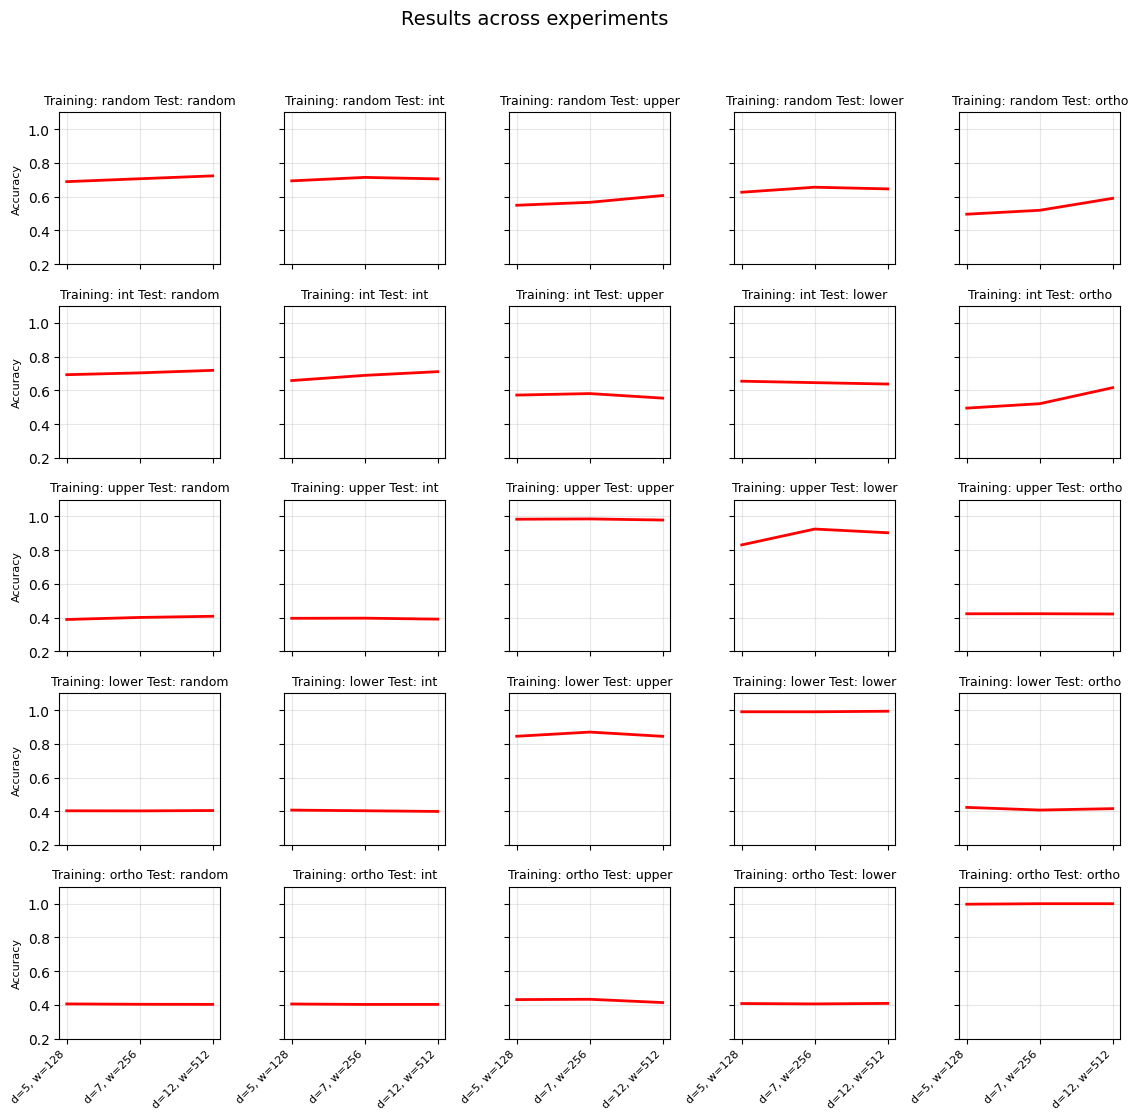

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# --- Plotting setup ---
dfs = [results0, results1, results2]
x_labels = ["d=5, w=128", "d=7, w=256", "d=12, w=512"]
x = np.arange(len(dfs))

rows = results0.index
cols = results0.columns

fig, axes = plt.subplots(
    len(rows), len(cols), figsize=(12, 12), sharex=True, sharey=True
)

for i, row in enumerate(rows):
    for j, col in enumerate(cols):
        ax = axes[i, j]
        y = [df.loc[row, col] for df in dfs]
        ax.plot(x, y, color="red", linestyle="-", linewidth=2)
        ax.set_ylim(0.2, 1.1)
        ax.set_title(f"Training: {row} Test: {col}", fontsize=9)
        ax.grid(alpha=0.3)
        if i == len(rows) - 1:
            ax.set_xticks(x)
            ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=8)
        else:
            ax.set_xticks([])
        if j == 0:
            ax.set_ylabel("Accuracy", fontsize=8)

# Global labels
# fig.text(0.5, 0.04, "Test S", ha='center', va='center', fontsize=12)
# fig.text(0.04, 0.5, "Training S", ha='center', va='center', rotation='vertical', fontsize=12)

fig.suptitle("Results across experiments", fontsize=14)
fig.tight_layout(rect=[0.05, 0.05, 1, 0.95])
plt.show()

Widać, że nie ma żadnej różnicy między losowaniem z macierzy przejścia całkowitych czy rzeczywistych. Używanie macierzy przejścia górnotrójkątnych w obu przypadkach pogorszyło rezultaty.

Model doskonale radzi sobie, gdy zawęzimy problem do sytuacji, gdy wektory własne/główne są do siebie ortogonalne (czego można było się spodziewać). Taką sytuację jednakże równie dobrze rozwiązuje obliczalny numerycznie rozkład Schura.

Z drugiej strony, wytrenowany na losowych danych model, słabo radzi sobie z rozróżnianiem wielkości bloków, gdy $S$ jest ortonormalna.